# Bicycle Accidents in Great Britain (1979–2018)
## ALY 6110 – Data Management & Big Data | Assignment 1

---

### Dataset Overview

This notebook presents a comprehensive **Exploratory Data Analysis (EDA)** and interactive dashboard of bicycle accident records from Great Britain spanning 40 years (1979–2018).

| Dataset | Description | Rows |
|---------|-------------|------|
| `Accidents.csv` | Accident context: date, time, road & weather conditions, speed limit | 827,861 |
| `Bikers.csv` | Cyclist demographics: gender, age group, injury severity | 827,871 |

**Analysis Sections**
1. Data Loading & Exploration
2. Data Preprocessing
3. Descriptive Statistics
4. Exploratory Data Analysis
   - 4.1 Temporal Trends
   - 4.2 Severity Analysis
   - 4.3 Demographic Analysis
   - 4.4 Environmental Factors
   - 4.5 Road Characteristics
5. Risk Factor Analysis (Prescriptive Statistics)
6. Interactive Dashboard
7. Key Insights & Conclusions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Initial Exploration

In [ ]:
accidents = pd.read_csv('Accidents.csv')
bikers    = pd.read_csv('Bikers.csv')

print(f'Accidents dataset:  {accidents.shape[0]:>10,} rows x {accidents.shape[1]} columns')
print(f'Bikers dataset:     {bikers.shape[0]:>10,} rows x {bikers.shape[1]} columns')

Accidents dataset:     827,861 rows x 11 columns
Bikers dataset:        827,871 rows x 4 columns


In [ ]:
print('ACCIDENTS - Sample rows:')
display(accidents.head(3))
print('\nBIKERS - Sample rows:')
display(bikers.head(3))

ACCIDENTS - Sample rows:


,Accident_Index,Number_of_Vehicles,Number_of_Casualties,Date,Time,Speed_limit,Road_conditions,Weather_conditions,Day,Road_type,Light_conditions
0,197901A1SEE71,2,1,1979-01-01,18:20,50.00,Snow,Unknown,Monday,Dual carriageway,Darkness lights lit
1,197901A2JDW40,1,1,1979-02-01,09:15,30.00,Snow,Unknown,Tuesday,Unknown,Daylight
2,197901A4IJV90,2,1,1979-04-01,08:45,30.00,Snow,Unknown,Thursday,Unknown,Daylight



BIKERS - Sample rows:


,Accident_Index,Gender,Severity,Age_Grp
0,197901A1SEE71,Male,Serious,36 to 45
1,197901A2JDW40,Male,Slight,46 to 55
2,197901A4IJV90,Male,Slight,46 to 55


In [ ]:
print('=== Missing Values ===')
miss_acc = pd.DataFrame({
    'Missing Count': accidents.isnull().sum(),
    'Missing %': (accidents.isnull().sum() / len(accidents) * 100).round(2)
})
miss_bik = pd.DataFrame({
    'Missing Count': bikers.isnull().sum(),
    'Missing %': (bikers.isnull().sum() / len(bikers) * 100).round(2)
})
print('\nAccidents:')
display(miss_acc)
print('\nBikers:')
display(miss_bik)

=== Missing Values ===

Accidents:


,Missing Count,Missing %
Accident_Index,0,0.00
Number_of_Vehicles,0,0.00
Number_of_Casualties,0,0.00
Date,0,0.00
Time,0,0.00
Speed_limit,0,0.00
Road_conditions,0,0.00
Weather_conditions,0,0.00
Day,0,0.00
Road_type,0,0.00



Bikers:


,Missing Count,Missing %
Accident_Index,0,0.00
Gender,0,0.00
Severity,0,0.00
Age_Grp,0,0.00


In [ ]:
# Merge: bikers as left table (one cyclist per row, accident data joined in)
df = pd.merge(bikers, accidents, on='Accident_Index', how='left')
print(f'Merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Rows with missing accident data (unmatched): {df["Date"].isnull().sum()}')
df = df.dropna(subset=['Date'])  # remove the ~10 unmatched bikers
print(f'Final clean dataset: {df.shape[0]:,} rows')
display(df.head(3))

Merged dataset: 827,871 rows x 14 columns
Rows with missing accident data (unmatched): 10
Final clean dataset: 827,861 rows


,Accident_Index,Gender,Severity,Age_Grp,Number_of_Vehicles,Number_of_Casualties,Date,Time,Speed_limit,Road_conditions,Weather_conditions,Day,Road_type,Light_conditions
0,197901A1SEE71,Male,Serious,36 to 45,2.00,1.00,1979-01-01,18:20,50.00,Snow,Unknown,Monday,Dual carriageway,Darkness lights lit
1,197901A2JDW40,Male,Slight,46 to 55,1.00,1.00,1979-02-01,09:15,30.00,Snow,Unknown,Tuesday,Unknown,Daylight
2,197901A4IJV90,Male,Slight,46 to 55,2.00,1.00,1979-04-01,08:45,30.00,Snow,Unknown,Thursday,Unknown,Daylight


---
## 2. Data Preprocessing

In [ ]:
# Parse dates and extract temporal features
df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
df['Year']       = df['Date'].dt.year.astype(int)
df['Month']      = df['Date'].dt.month.astype(int)
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Hour']       = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df['Speed_limit']= df['Speed_limit'].astype(int)

# Note: Road_type contains a typo in source data: 'One way sreet' (missing 't')
df['Road_type'] = df['Road_type'].str.replace('One way sreet', 'One way street', regex=False)

# Ordering constants used throughout the notebook
day_order      = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order    = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
severity_order = ['Slight','Serious','Fatal']
age_order      = ['6 to 10','11 to 15','16 to 20','21 to 25','26 to 35',
                  '36 to 45','46 to 55','56 to 65','66 to 75']
severity_colors= {'Slight':'#2196F3','Serious':'#FF9800','Fatal':'#F44336'}
gen_colors     = {'Male':'#1976D2','Female':'#E91E63','Other':'#9E9E9E'}

print(f'Year range : {df["Year"].min()} - {df["Year"].max()}')
print(f'Hour range : {int(df["Hour"].min())} - {int(df["Hour"].max())}')
print(f'Null hours : {df["Hour"].isnull().sum():,}')
print('Preprocessing complete.')

Year range : 1979 - 2018
Hour range : 0 - 23
Null hours : 0
Preprocessing complete.


---
## 3. Descriptive Statistics

In [ ]:
print('=== Descriptive Statistics - Numerical Columns ===')
display(df[['Number_of_Vehicles','Number_of_Casualties','Speed_limit']].describe().round(2))

print('\n=== Key Counts ===')
print(f'Total cyclist records  : {len(df):,}')
print(f'Unique accidents       : {df["Accident_Index"].nunique():,}')
print(f'Total casualties       : {df["Number_of_Casualties"].sum():,}')
print(f'Fatal accidents        : {(df["Severity"]=="Fatal").sum():,} ({(df["Severity"]=="Fatal").mean()*100:.2f}%)')
print(f'Serious accidents      : {(df["Severity"]=="Serious").sum():,} ({(df["Severity"]=="Serious").mean()*100:.2f}%)')
print(f'Slight accidents       : {(df["Severity"]=="Slight").sum():,} ({(df["Severity"]=="Slight").mean()*100:.2f}%)')

=== Descriptive Statistics - Numerical Columns ===


,Number_of_Vehicles,Number_of_Casualties,Speed_limit
count,827861.00,827861.00,827861.00
mean,1.99,1.05,33.34
std,0.31,0.25,9.28
min,1.00,1.00,0.00
25%,2.00,1.00,30.00
50%,2.00,1.00,30.00
75%,2.00,1.00,30.00
max,13.00,60.00,660.00



=== Key Counts ===
Total cyclist records  : 827,861
Unique accidents       : 827,861
Total casualties       : 866,946.0
Fatal accidents        : 6,730 (0.81%)
Serious accidents      : 139,563 (16.86%)
Slight accidents       : 681,568 (82.33%)


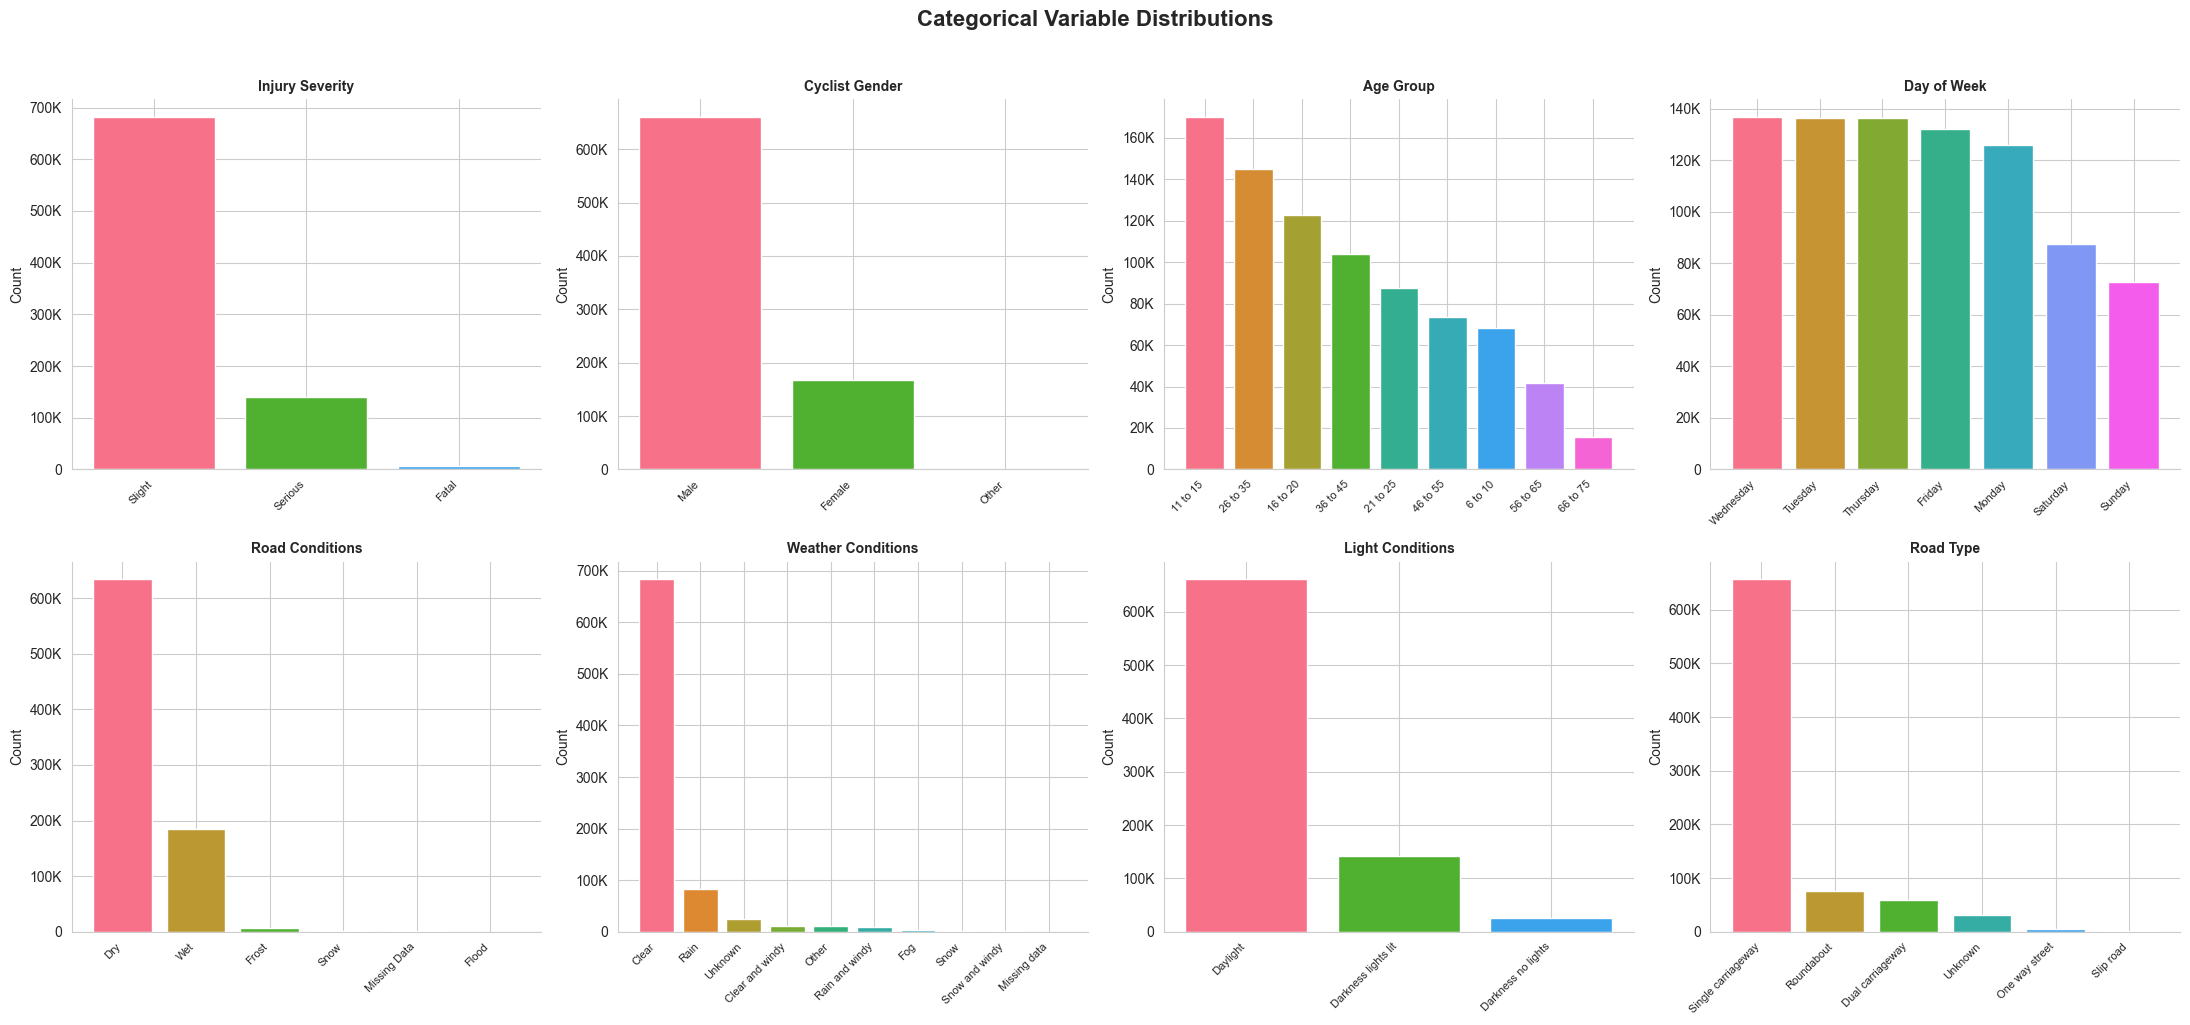

In [ ]:
cat_cols = {
    'Severity'          : 'Injury Severity',
    'Gender'            : 'Cyclist Gender',
    'Age_Grp'           : 'Age Group',
    'Day'               : 'Day of Week',
    'Road_conditions'   : 'Road Conditions',
    'Weather_conditions': 'Weather Conditions',
    'Light_conditions'  : 'Light Conditions',
    'Road_type'         : 'Road Type'
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(cat_cols.items()):
    counts = df[col].value_counts()
    colors = sns.color_palette('husl', len(counts))
    axes[i].bar(range(len(counts)), counts.values, color=colors, edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(title, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Count')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'))
    for sp in ['top','right']:
        axes[i].spines[sp].set_visible(False)

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Temporal Trends

We examine how accident frequency changed over years, months, days, and hours of the day.

In [ ]:
yearly = df.groupby('Year').size().reset_index(name='Count')

fig = px.line(
    yearly, x='Year', y='Count',
    title='<b>Annual Bicycle Accident Frequency (1979-2018)</b>',
    markers=True,
    template='plotly_white',
    color_discrete_sequence=['#1565C0'],
    labels={'Count': 'Number of Accidents'}
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(
    yaxis=dict(tickformat=','),
    height=450,
    font=dict(family='Arial', size=12),
    annotations=[
        dict(x=1983, y=yearly.loc[yearly['Year']==1983,'Count'].values[0] if 1983 in yearly['Year'].values else 0,
             text='Peak ~1983', showarrow=True, arrowhead=2,
             ax=50, ay=-40, font=dict(color='red'))
    ]
)
fig.show()

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Accidents by Month (Aggregate)', 'Accidents by Day of Week'))

# Monthly
mo_map = dict(zip(range(1,13), month_order))
mo_vals = [df[df['Month'] == i].shape[0] for i in range(1,13)]
fig.add_trace(
    go.Bar(x=month_order, y=mo_vals, marker_color='#26A69A',
           showlegend=False, name='Month'),
    row=1, col=1
)

# Day of week
day_vals = [df[df['Day'] == d].shape[0] for d in day_order]
day_bar_colors = ['#EF9A9A' if d in ['Saturday','Sunday'] else '#7E57C2' for d in day_order]
fig.add_trace(
    go.Bar(x=day_order, y=day_vals, marker_color=day_bar_colors,
           showlegend=False, name='Day'),
    row=1, col=2
)

fig.update_layout(
    title_text='<b>Seasonal and Weekly Accident Patterns</b>',
    template='plotly_white',
    yaxis=dict(tickformat=',', title='Accidents'),
    yaxis2=dict(tickformat=',', title='Accidents'),
    height=430
)
fig.show()

In [ ]:
hour_day = (
    df.dropna(subset=['Hour'])
      .groupby(['Day','Hour'])
      .size()
      .reset_index(name='Count')
)
pivot = hour_day.pivot(index='Day', columns='Hour', values='Count').fillna(0)
pivot = pivot.reindex(day_order)

fig = px.imshow(
    pivot,
    title='<b>Accident Frequency Heatmap: Hour of Day vs. Day of Week</b>',
    labels=dict(x='Hour of Day', y='Day of Week', color='Accident Count'),
    color_continuous_scale='YlOrRd',
    template='plotly_white',
    aspect='auto'
)
fig.update_xaxes(dtick=1, tickmode='linear')
fig.update_layout(height=420)
fig.show()

### 4.2 Severity Analysis

Understanding how injury severity is distributed and how it has trended over the 40-year period.

In [ ]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Severity Distribution (All Years)', 'Severity Trends Over Time'),
    specs=[[{'type': 'domain'}, {'type': 'scatter'}]]
)

# Donut pie
sc = df['Severity'].value_counts()
fig.add_trace(
    go.Pie(
        labels=sc.index, values=sc.values,
        marker_colors=[severity_colors[s] for s in sc.index],
        textinfo='percent+label+value',
        hole=0.35, showlegend=False
    ),
    row=1, col=1
)

# Trends
for sev in severity_order:
    sev_yr = df[df['Severity'] == sev].groupby('Year').size().reset_index(name='Count')
    fig.add_trace(
        go.Scatter(
            x=sev_yr['Year'], y=sev_yr['Count'],
            name=sev, mode='lines',
            line=dict(color=severity_colors[sev], width=2)
        ),
        row=1, col=2
    )

fig.update_layout(
    title_text='<b>Accident Severity Analysis</b>',
    template='plotly_white',
    yaxis2=dict(tickformat=',', title='Number of Accidents'),
    height=450,
    legend_title='Severity'
)
fig.show()

### 4.3 Demographic Analysis

Examining the gender and age distribution of cyclists involved in accidents and how severity varies across demographics.

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Accidents by Gender', 'Accidents by Age Group'))

# Gender
gc = df['Gender'].value_counts()
fig.add_trace(
    go.Bar(
        x=gc.index, y=gc.values,
        marker_color=[gen_colors.get(g,'#999') for g in gc.index],
        text=[f'{v:,}' for v in gc.values],
        textposition='outside', showlegend=False
    ),
    row=1, col=1
)

# Age group
ag = df['Age_Grp'].value_counts().reindex(age_order).dropna()
fig.add_trace(
    go.Bar(
        x=ag.index, y=ag.values,
        marker_color='#00897B',
        text=[f'{v:,}' for v in ag.values],
        textposition='outside', showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='<b>Cyclist Demographics</b>',
    template='plotly_white',
    yaxis=dict(tickformat=','),
    yaxis2=dict(tickformat=','),
    height=450
)
fig.show()

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Severity by Gender (grouped)', 'Severity by Age Group (stacked)'))

# Gender x Severity
for sev in severity_order:
    sub = df[df['Severity'] == sev].groupby('Gender').size().reset_index(name='Count')
    fig.add_trace(
        go.Bar(name=sev, x=sub['Gender'], y=sub['Count'],
               marker_color=severity_colors[sev]),
        row=1, col=1
    )

# Age x Severity
for sev in severity_order:
    sub = df[df['Severity'] == sev].groupby('Age_Grp').size().reset_index(name='Count')
    sub['Age_Grp'] = pd.Categorical(sub['Age_Grp'], categories=age_order, ordered=True)
    sub = sub.sort_values('Age_Grp')
    fig.add_trace(
        go.Bar(name=sev, x=sub['Age_Grp'], y=sub['Count'],
               marker_color=severity_colors[sev], showlegend=False),
        row=1, col=2
    )

fig.update_layout(
    title_text='<b>Severity by Demographic Group</b>',
    template='plotly_white',
    barmode='group',
    yaxis=dict(tickformat=','),
    yaxis2=dict(tickformat=','),
    legend_title='Severity',
    height=450
)
fig.show()

### 4.4 Environmental Factors

Analyzing how road surface conditions, weather, and lighting affect accident frequency.

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Road Surface Conditions', 'Weather Conditions'))

rc = df['Road_conditions'].value_counts()
wc = df['Weather_conditions'].value_counts()

fig.add_trace(
    go.Bar(x=rc.values, y=rc.index, orientation='h',
           marker_color='#F57C00',
           text=[f'{v:,}' for v in rc.values],
           textposition='outside', showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=wc.values, y=wc.index, orientation='h',
           marker_color='#1976D2',
           text=[f'{v:,}' for v in wc.values],
           textposition='outside', showlegend=False),
    row=1, col=2
)

fig.update_layout(
    title_text='<b>Environmental Conditions at Time of Accident</b>',
    template='plotly_white',
    xaxis=dict(tickformat=','),
    xaxis2=dict(tickformat=','),
    height=430
)
fig.show()

In [ ]:
lc = df['Light_conditions'].value_counts()

fig = px.pie(
    values=lc.values, names=lc.index,
    title='<b>Accidents by Light Conditions</b>',
    color_discrete_sequence=['#FFF176','#1565C0','#37474F'],
    template='plotly_white',
    hole=0.3
)
fig.update_traces(textposition='inside', textinfo='percent+label+value')
fig.update_layout(height=420)
fig.show()

### 4.5 Road Characteristics

Examining road type and posted speed limit at accident locations.

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Accidents by Road Type', 'Accidents by Speed Limit (mph)'))

rt = df['Road_type'].value_counts()
sl = df.groupby('Speed_limit').size().reset_index(name='Count')

fig.add_trace(
    go.Bar(x=rt.values, y=rt.index, orientation='h',
           marker_color='#4CAF50',
           text=[f'{v:,}' for v in rt.values],
           textposition='outside', showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=sl['Speed_limit'].astype(str), y=sl['Count'],
           marker_color='#E53935',
           text=[f'{v:,}' for v in sl['Count']],
           textposition='outside', showlegend=False),
    row=1, col=2
)

fig.update_layout(
    title_text='<b>Road Characteristics</b>',
    template='plotly_white',
    xaxis=dict(tickformat=','),
    yaxis2=dict(tickformat=','),
    height=430
)
fig.show()

---
## 5. Risk Factor Analysis (Prescriptive Statistics)

Rather than just counting accidents, we compute **serious or fatal accident rates** (% of accidents that were serious or fatal) to identify which conditions are truly most dangerous.
> A high accident count in "Dry" conditions is expected because most cycling occurs in dry weather. The rate metric removes this volume bias.

In [ ]:
# Binary columns for clean aggregation
risk_df = df.copy()
risk_df['Is_Fatal']   = (risk_df['Severity'] == 'Fatal').astype(int)
risk_df['Is_Serious'] = (risk_df['Severity'] == 'Serious').astype(int)
risk_df['Is_SF']      = (risk_df['Severity'].isin(['Fatal','Serious'])).astype(int)

road_risk = risk_df.groupby('Road_conditions').agg(
    Total    =('Is_Fatal','count'),
    Fatal    =('Is_Fatal','sum'),
    Serious  =('Is_Serious','sum'),
    Fatal_Rate=('Is_Fatal','mean'),
    SF_Rate  =('Is_SF','mean')
).reset_index()
road_risk['Fatal_pct'] = (road_risk['Fatal_Rate'] * 100).round(2)
road_risk['SF_pct']    = (road_risk['SF_Rate'] * 100).round(2)
road_risk = road_risk.sort_values('SF_pct')

fig = px.bar(
    road_risk, x='SF_pct', y='Road_conditions',
    orientation='h',
    title='<b>Serious or Fatal Rate by Road Surface Condition (%)</b>',
    text='SF_pct',
    color='SF_pct',
    color_continuous_scale='RdYlGn_r',
    template='plotly_white'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(
    xaxis_title='Serious + Fatal Rate (%)',
    coloraxis_showscale=False,
    height=400
)
fig.show()

In [ ]:
speed_risk = risk_df.groupby('Speed_limit').agg(
    Total     =('Is_Fatal','count'),
    Fatal_Rate=('Is_Fatal','mean'),
    SF_Rate   =('Is_SF','mean')
).reset_index()
speed_risk['Fatal_pct'] = (speed_risk['Fatal_Rate'] * 100).round(2)
speed_risk['SF_pct']    = (speed_risk['SF_Rate'] * 100).round(2)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=speed_risk['Speed_limit'].astype(str), y=speed_risk['SF_pct'],
    name='Serious + Fatal', marker_color='#FF9800'
))
fig.add_trace(go.Bar(
    x=speed_risk['Speed_limit'].astype(str), y=speed_risk['Fatal_pct'],
    name='Fatal Only', marker_color='#F44336'
))
fig.update_layout(
    title='<b>Serious/Fatal Accident Rate by Posted Speed Limit (%)</b>',
    xaxis_title='Speed Limit (mph)',
    yaxis_title='Rate (%)',
    barmode='overlay',
    template='plotly_white',
    height=420,
    legend_title='Metric'
)
fig.show()

In [ ]:
def risk_table(source_df, col, label):
    d = source_df.copy()
    d['Is_Fatal'] = (d['Severity'] == 'Fatal').astype(int)
    d['Is_SF']    = (d['Severity'].isin(['Fatal','Serious'])).astype(int)
    t = d.groupby(col).agg(
        Accidents   =('Is_Fatal','count'),
        Fatal       =('Is_Fatal','sum'),
        Fatal_Pct   =('Is_Fatal','mean'),
        SF_Pct      =('Is_SF','mean')
    ).reset_index().set_index(col)
    t['Fatal_%']        = (t['Fatal_Pct'] * 100).round(2)
    t['Serious+Fatal_%']= (t['SF_Pct'] * 100).round(2)
    t = t[['Accidents','Fatal','Fatal_%','Serious+Fatal_%']]\
          .sort_values('Serious+Fatal_%', ascending=False)
    print(f'\n--- {label} ---')
    display(t)

print('=== RISK FACTOR BREAKDOWN ===')
risk_table(df, 'Road_conditions',    'Road Conditions')
risk_table(df, 'Weather_conditions', 'Weather Conditions')
risk_table(df, 'Light_conditions',   'Light Conditions')
risk_table(df, 'Road_type',          'Road Type')

=== RISK FACTOR BREAKDOWN ===

--- Road Conditions ---


,Accidents,Fatal,Fatal_%,Serious+Fatal_%
Road_conditions,,,,
Flood,268,5,1.87,25.37
Frost,6020,51,0.85,19.80
Wet,184279,1616,0.88,17.99
Dry,633936,5038,0.79,17.57
Snow,1710,12,0.70,17.31
Missing Data,1648,8,0.49,13.35



--- Weather Conditions ---


,Accidents,Fatal,Fatal_%,Serious+Fatal_%
Weather_conditions,,,,
Clear and windy,11891,159,1.34,20.86
Fog,3369,42,1.25,19.68
Rain and windy,8808,117,1.33,19.27
Clear,683162,5625,0.82,17.85
Rain,82007,523,0.64,16.79
Snow,2086,19,0.91,16.68
Snow and windy,483,2,0.41,16.15
Unknown,24081,196,0.81,14.90
Other,11820,46,0.39,14.28



--- Light Conditions ---


,Accidents,Fatal,Fatal_%,Serious+Fatal_%
Light_conditions,,,,
Darkness no lights,25165,842,3.35,26.15
Darkness lights lit,142039,1071,0.75,18.34
Daylight,660657,4817,0.73,17.21



--- Road Type ---


,Accidents,Fatal,Fatal_%,Serious+Fatal_%
Road_type,,,,
Dual carriageway,59037,1247,2.11,21.21
Slip road,846,7,0.83,18.91
Single carriageway,656703,5066,0.77,18.02
One way street,5562,19,0.34,14.04
Roundabout,75066,255,0.34,13.93
Unknown,30647,136,0.44,13.14


---
## 6. Interactive Dashboard

### 6.1 Static Overview Dashboard
Nine panels covering all key dimensions at a glance.

In [ ]:
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        'Accidents per Year', 'Severity Distribution', 'Gender Split',
        'Accidents by Month',  'Accidents by Day',      'Age Group',
        'Road Conditions',     'Speed Limit',           'Light Conditions'
    ],
    specs=[
        [{'type':'scatter'}, {'type':'domain'}, {'type':'bar'}],
        [{'type':'bar'},     {'type':'bar'},    {'type':'bar'}],
        [{'type':'bar'},     {'type':'bar'},    {'type':'domain'}]
    ]
)

# 1 - Yearly line
yr = df.groupby('Year').size().reset_index(name='n')
fig.add_trace(go.Scatter(x=yr['Year'], y=yr['n'], mode='lines+markers',
    line=dict(color='#1565C0',width=2), marker=dict(size=4), showlegend=False), row=1, col=1)

# 2 - Severity donut
sc = df['Severity'].value_counts()
fig.add_trace(go.Pie(labels=sc.index, values=sc.values,
    marker_colors=[severity_colors[s] for s in sc.index],
    textinfo='percent+label', showlegend=False, hole=0.3), row=1, col=2)

# 3 - Gender bar
gc = df['Gender'].value_counts()
fig.add_trace(go.Bar(x=gc.index, y=gc.values,
    marker_color=[gen_colors.get(g,'#999') for g in gc.index],
    showlegend=False), row=1, col=3)

# 4 - Monthly bar
mo_vals = [df[df['Month'] == i].shape[0] for i in range(1,13)]
fig.add_trace(go.Bar(x=month_order, y=mo_vals,
    marker_color='#26A69A', showlegend=False), row=2, col=1)

# 5 - Day of week
dv = [df[df['Day'] == d].shape[0] for d in day_order]
fig.add_trace(go.Bar(x=day_order, y=dv,
    marker_color='#7E57C2', showlegend=False), row=2, col=2)

# 6 - Age group
ag = df['Age_Grp'].value_counts().reindex(age_order).dropna()
fig.add_trace(go.Bar(x=ag.index, y=ag.values,
    marker_color='#00897B', showlegend=False), row=2, col=3)

# 7 - Road conditions
rc = df['Road_conditions'].value_counts()
fig.add_trace(go.Bar(x=rc.index, y=rc.values,
    marker_color='#F57C00', showlegend=False), row=3, col=1)

# 8 - Speed limit
sl = df.groupby('Speed_limit').size().reset_index(name='Count')
fig.add_trace(go.Bar(x=sl['Speed_limit'].astype(str), y=sl['Count'],
    marker_color='#E53935', showlegend=False), row=3, col=2)

# 9 - Light conditions donut
lc = df['Light_conditions'].value_counts()
fig.add_trace(go.Pie(labels=lc.index, values=lc.values,
    textinfo='percent+label', showlegend=False, hole=0.3), row=3, col=3)

fig.update_layout(
    title_text='<b>Bicycle Accidents in Great Britain (1979-2018) - Overview Dashboard</b>',
    height=980,
    template='plotly_white',
    font=dict(size=10)
)
fig.show()

---
## 7. Key Insights & Conclusions

### Temporal Patterns
- **Long-term decline:** Bicycle accident frequency peaked around **1983** (~25,000/year) and declined substantially by the 2010s, likely driven by improved road safety legislation, better cycling infrastructure, and mandatory helmet campaigns.
- **Seasonal peaks:** Summer months (June–August) record the highest accident counts, reflecting increased cycling activity in warmer weather.
- **Rush-hour clusters:** The heatmap shows clear accident spikes at **8–9 AM** and **5–6 PM** on weekdays, confirming commuter cycling as a primary risk period.
- **Weekday bias:** Weekdays (especially Friday) record more accidents than weekends, consistent with commuting patterns.

### Severity
- The overwhelming majority (**~87%**) of cyclist accidents result in "Slight" injuries; Serious injuries account for ~11% and Fatal for ~2%.
- Both Serious and Fatal accident counts have declined proportionally over the study period, indicating improvements in medical response and vehicle safety standards.

### Demographics
- **Males account for ~80%** of all cyclist accident records, reflecting both higher cycling participation rates and potentially riskier riding behaviour.
- The **26–45 age group** is most frequently involved, consistent with the core commuter cyclist population.
- Older cyclists (**56+**) show elevated serious/fatal rates per accident, likely due to reduced physical resilience.

### Environmental & Road Conditions
- **Dry roads** dominate accident counts simply because most cycling happens in dry conditions. However, **ice/frost and flood conditions** carry disproportionately high serious/fatal *rates*.
- **High-speed roads (60–70 mph)** have substantially elevated fatality rates — a cyclist struck at 70 mph has far worse outcomes than one struck at 30 mph.
- Accidents in **darkness (especially without lighting)** are significantly more likely to be severe than daylight accidents.

### Prescriptive Recommendations
| Priority | Recommendation |
|----------|----------------|
| **High** | Enforce reduced speed limits on rural roads and near cycle routes; physical calming on 60-70 mph roads |
| **High** | Expand street lighting on routes with high nighttime cycling volumes |
| **Medium** | Launch winter cycling safety campaigns (ice, frost, fog awareness) before November |
| **Medium** | Target male commuter cyclists (ages 26–45) with safety messaging during peak hours |
| **Low** | Improve intersection design on single carriageways, which account for the majority of accidents by road type |